In [3]:
netlist = """\
BJT Output Characteristics
Vce vce 0 DC $VCE_MAX
Ib  0 base DC $IB
Q1  vce base 0 BC547

.MODEL BC547 NPN(Is=1e-14 Bf=200 Vaf=100)

.DC Vce $VCE_START $VCE_MAX $VCE_STEP Ib $IB_START $IB_STOP $IB_STEP

.SAVE $SAVE_VARS
.END
"""

with open('bjt_sweep_orig.cir', 'w') as f:
    f.write(netlist)

print("bjt_sweep_orig.cir written")

bjt_sweep_orig.cir written


In [4]:
import ngspice_calc as calc
import numpy as np
import matplotlib.pyplot as plt

vce_start = 0.0
vce_stop = 10.0
vce_step = 0.1

ib_start = 50e-6
ib_stop = 80e-6
ib_step = 10e-6

n_inner = int(round((vce_stop - vce_start) / vce_step))+1
n_outer = int(round((ib_stop - ib_start) / ib_step))+1
ib_values = np.arange(ib_start, ib_stop + ib_step/2, ib_step)

print(f'VCE points per curve: {n_inner}')
print(f'Number of IB curves: {n_outer}')
print(f'IB values: {ib_values*1e6} uA')

VCE points per curve: 101
Number of IB curves: 4
IB values: [50. 60. 70. 80.] uA


In [5]:
l = [
    ('$VCE_START', f'{vce_start}'),
    ('$VCE_MAX', f'{vce_stop}'),
    ('$VCE_STEP', f'{vce_step}'),
    ('$IB_START', f'{ib_start:.2e}'),
    ('$IB_STOP', f'{ib_stop:.2e}'),
    ('$IB_STEP', f'{ib_step:.2e}'),
    ('$IB', f'{ib_start:.2e}'),
    ('$SAVE_VARS', f'i(Vce)')
]

calc.replace_strings_1('bjt_sweep_orig.cir', 'bjt_sweep.cir', l)

In [6]:
calc.run_ngspice('bjt_sweep.cir')

Linux

Note: No compatibility mode selected!


Circuit: bjt output characteristics

binary raw file "bjt_sweep.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
No. of Data Columns : 2  

No. of Data Rows : 404

Total analysis time (seconds) = 0.00227447

Total elapsed time (seconds) = 0.016 

Total DRAM available = 15614.742 MB.
DRAM currently available = 1182.879 MB.
Maximum ngspice program size =   21.402 MB.
Current ngspice program size =   12.590 MB.

Shared ngspice pages =   10.812 MB.
Text (code) pages =    7.105 MB.
Stack = 0 bytes.
Library pages =    1.875 MB.




'bjt_sweep.raw'

In [7]:
s = calc.slv('bjt_sweep.cir')

for i in range(s.num_plots()):
    print(f"plot {i}: {s.plotname(i)} | type: {s.analysis_type(i)} | vars: {s.variables(i)}")

plot 0: DC transfer characteristic | type: tran | vars: ['v(v-sweep)', 'i(vce)']


In [8]:
vce_curves = s.get_dc_sweep('v(v-sweep)', n_inner)
ic_curves = s.get_dc_sweep('i(vce)', n_inner)

ic_curves = [-c for c in ic_curves]

print(f'Number of curves: {len(ic_curves)}')
print(f'Points per curve: {len(ic_curves[0])}')

Number of curves: 4
Points per curve: 101


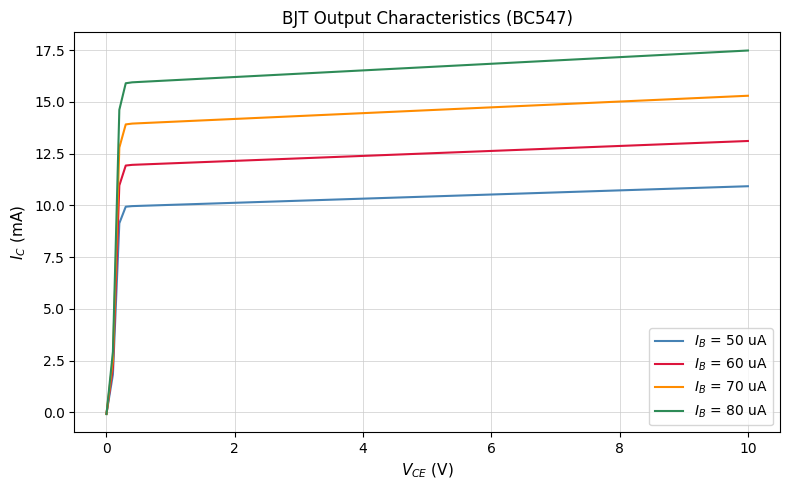

In [9]:
colors = ['steelblue', 'crimson', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(8, 5))
ax.grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)

for i, (vce, ic) in enumerate(zip(vce_curves, ic_curves)):
    ax.plot(vce, ic * 1e3, color=colors[i], linewidth=1.5,
            label=f'$I_B$ = {ib_values[i]*1e6:.0f} uA')

ax.set_xlabel('$V_{CE}$ (V)', fontsize=11)
ax.set_ylabel('$I_C$ (mA)', fontsize=11)
ax.set_title('BJT Output Characteristics (BC547)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()